In [1]:
import cv2
import matplotlib.pyplot as plt

def count_faces(image_path):
    """
    Counts the number of faces in an image using OpenCV's Haar Cascade.

    Args:
        image_path (str): The path to the input image file.

    Returns:
        int: The number of faces detected in the image.
        numpy.ndarray: The image with detected faces highlighted (if any).
    """
    # Load the pre-trained face detection model (Haar Cascade Classifier)
    # You might need to download 'haarcascade_frontalface_default.xml' if not already present.
    # A common path is within the OpenCV installation: cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    # Read the image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return 0, None

    # Convert the image to grayscale, as face detection works on grayscale images
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces in the grayscale image
    # The parameters are tuned for general use; they might need adjustment for specific cases
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,     # How much the image size is reduced at each image scale
        minNeighbors=5,      # How many neighbors each candidate rectangle should have to retain it
        minSize=(30, 30),    # Minimum possible object size. Objects smaller than that are ignored.
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    # Draw rectangles around the detected faces
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2) # Blue rectangle, 2px thickness

    return len(faces), img


### Example Usage:

To use the function, you'll need an image file. If you don't have one readily available, you can download a sample image or upload one to your Colab environment. For example, you can use `wget` to download an image from the internet.

Let's try to download a sample image and then use the function to count faces.

--2026-03-07 05:11:59--  https://upload.wikimedia.org/wikipedia/commons/thumb/8/8d/President_Barack_Obama.jpg/220px-President_Barack_Obama.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.154.240, 2620:0:861:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.154.240|:443... connected.
HTTP request sent, awaiting response... 429 Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further information (a765913)
2026-03-07 05:11:59 ERROR 429: Use thumbnail steps listed on https://w.wiki/GHai. Please contact noc@wikimedia.org for further information (a765913).

Number of faces detected: 3


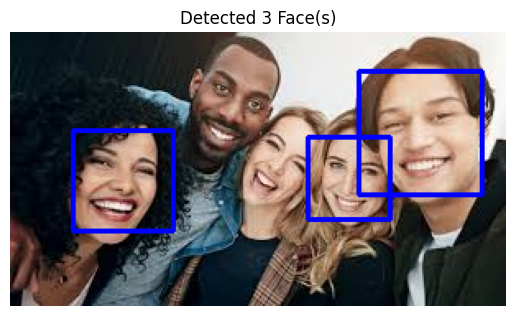

In [2]:
# Download a sample image (replace with your desired image path)
!wget -O sample_face.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/8/8d/President_Barack_Obama.jpg/220px-President_Barack_Obama.jpg

# Or, if you want to upload a local file:
# from google.colab import files
# uploaded = files.upload()
# image_path = list(uploaded.keys())[0]

image_path = 'images.06.jpg'

num_faces, img_with_faces = count_faces(image_path)

print(f"Number of faces detected: {num_faces}")

if img_with_faces is not None:
    # Display the image with detected faces
    plt.imshow(cv2.cvtColor(img_with_faces, cv2.COLOR_BGR2RGB))
    plt.title(f'Detected {num_faces} Face(s)')
    plt.axis('off')
    plt.show()